this cell only needs to be run once to filter dataset, unless we decide to chagne hwo we filter it no need to run again

In [2]:
# import pandas as pd

# # Path to dataset
# filepath = "Datasets/chicago_full.csv"

# # Load dataset
# df = pd.read_csv(filepath, engine="python", on_bad_lines="skip")

# # Convert Date column to datetime
# df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p")

# # Filter rows between 2021 and 2026
# filtered_df = df[(df["Date"] >= "2021-03-07") & (df["Date"] <= "2026-03-7")]

# # Save result
# filtered_df.to_csv("Datasets/chicago_filtered.csv", index=False)

# print("Filtered dataset saved.")

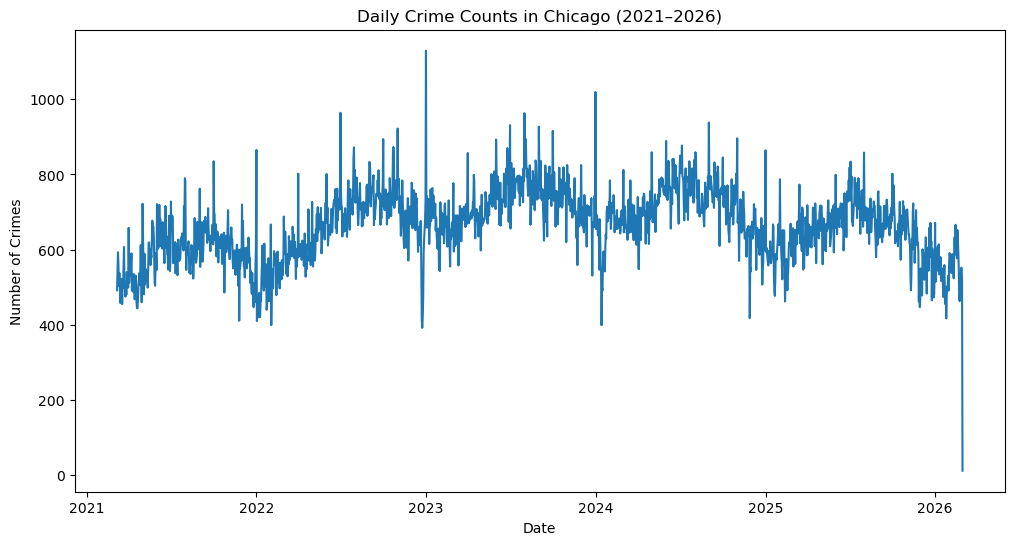

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

filepath = "Datasets/chicago_filtered.csv"

df = pd.read_csv(filepath, engine="python", on_bad_lines="skip")

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Create daily counts
daily_crime = df.resample('D', on='Date').size()

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_crime)
plt.title("Daily Crime Counts in Chicago (2021–2026)")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")
plt.savefig("Outputs/crime_counts_day.png", bbox_inches="tight")
plt.show()



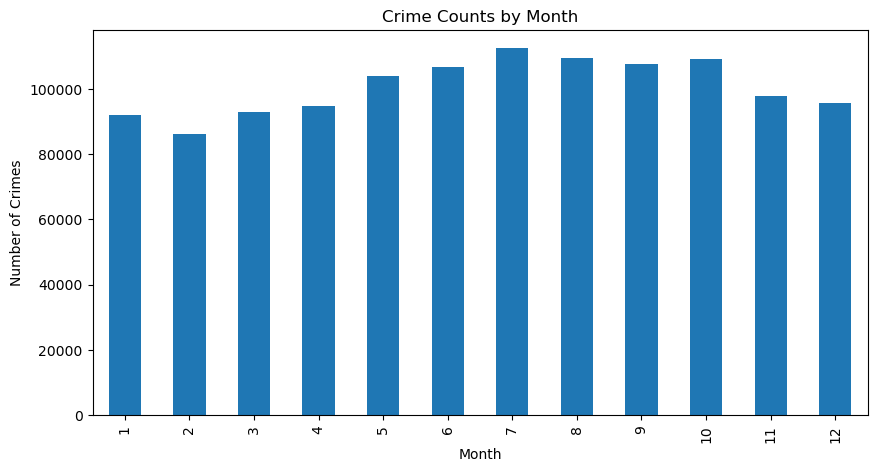

In [4]:
df['Month'] = df['Date'].dt.month

monthly_counts = df.groupby(['Month']).size()

plt.figure(figsize=(10,5))
monthly_counts.plot(kind='bar')
plt.title("Crime Counts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.savefig("Outputs/crime_counts_month.png", bbox_inches="tight")
plt.show()




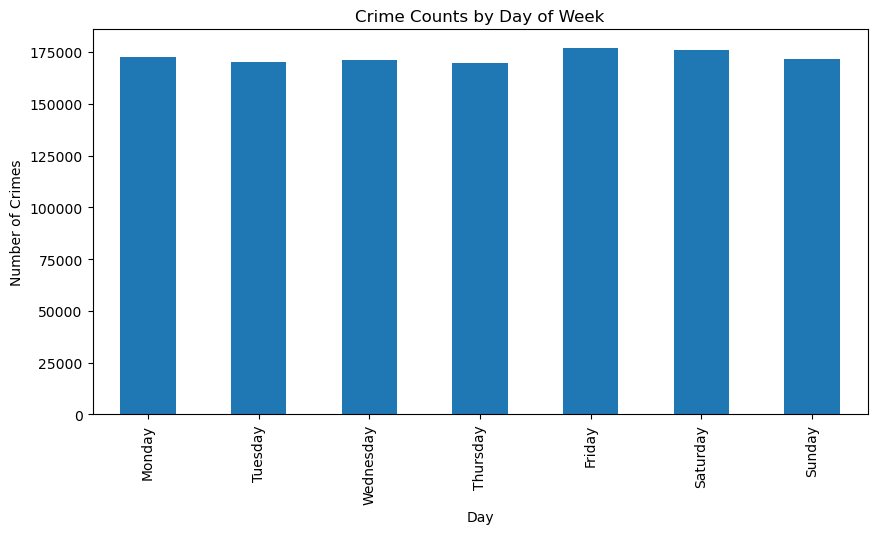

In [5]:
df['DayOfWeek'] = df['Date'].dt.day_name()

dow_counts = df.groupby('DayOfWeek').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,5))
dow_counts.plot(kind='bar')
plt.title("Crime Counts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")
plt.savefig("Outputs/crime_counts_dayofweek.png", bbox_inches="tight")
plt.show()



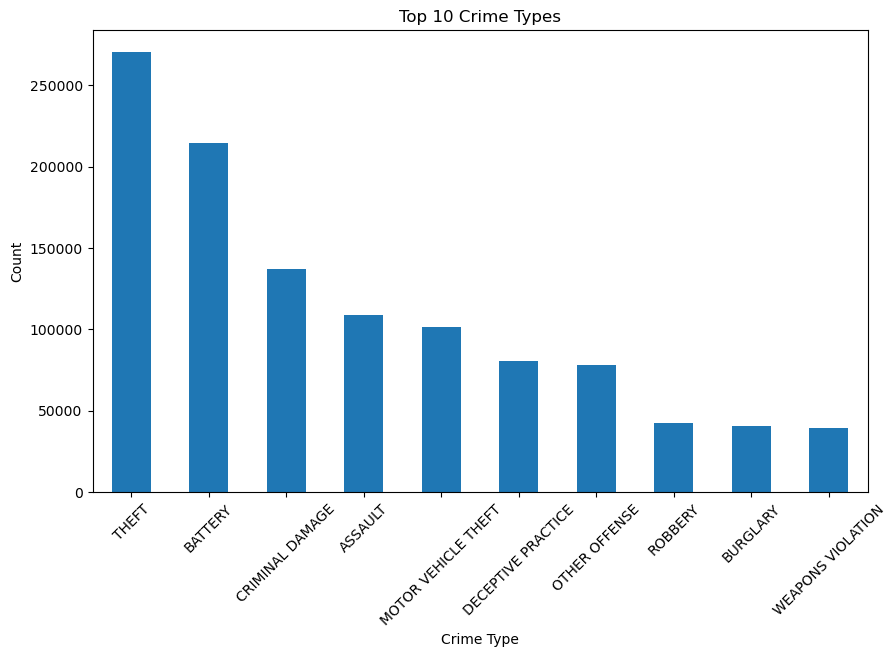

In [6]:
crime_types = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
crime_types.plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("Outputs/crime_top_types.png", bbox_inches="tight")
plt.show()



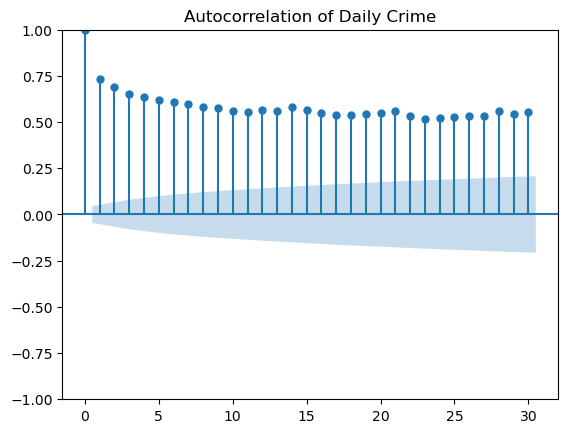

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_crime, lags=30)
plt.title("Autocorrelation of Daily Crime")
plt.savefig("Outputs/crime_autocorrelation.png", bbox_inches="tight")
plt.show()